In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("../data/student_marks.csv")

In [3]:
data

,Hours,Marks
0,1,18
1,2,25
2,3,35
3,4,45
4,5,58
5,6,67
6,7,77
7,8,86
8,9,93
9,10,98


In [4]:
data.head()

,Hours,Marks
0,1,18
1,2,25
2,3,35
3,4,45
4,5,58


In [5]:
data.tail()

,Hours,Marks
5,6,67
6,7,77
7,8,86
8,9,93
9,10,98


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Hours   10 non-null     int64
 1   Marks   10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


In [7]:
data.describe()

,Hours,Marks
count,10.00000,10.000000
mean,5.50000,60.200000
std,3.02765,28.654261
min,1.00000,18.000000
25%,3.25000,37.500000
50%,5.50000,62.500000
75%,7.75000,83.750000
max,10.00000,98.000000


In [8]:
x = data[["Hours"]]
y = data["Marks"]

In [9]:
x

,Hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [10]:
y

0    18
1    25
2    35
3    45
4    58
5    67
6    77
7    86
8    93
9    98
Name: Marks, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

In [13]:
x_train

,Hours
5,6
0,1
7,8
2,3
9,10
4,5
3,4
6,7


In [14]:
x_test

,Hours
8,9
1,2


In [15]:
y_train

5    67
0    18
7    86
2    35
9    98
4    58
3    45
6    77
Name: Marks, dtype: int64

In [16]:
y

0    18
1    25
2    35
3    45
4    58
5    67
6    77
7    86
8    93
9    98
Name: Marks, dtype: int64

In [17]:
y_test

8    93
1    25
Name: Marks, dtype: int64

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model = LinearRegression()

In [20]:
model.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9.31]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.293
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [21]:
y_pred = model.predict(x_test)

In [22]:
y_pred

array([93.0862069, 27.9137931])

In [23]:
from sklearn.metrics import r2_score

In [24]:
r2_score(y_test , y_pred)

0.9963245580109361

In [25]:
model.predict([[12]])

C:\Users\aryan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([121.01724138])

In [26]:
model.predict([[4]])
              

C:\Users\aryan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([46.53448276])

In [27]:
import matplotlib.pyplot as plt

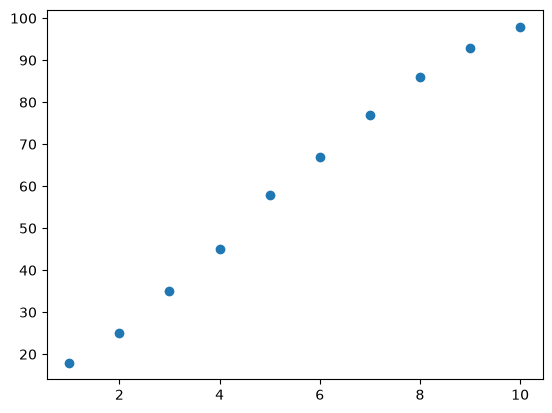

In [28]:
plt.scatter(x,y)
plt.show()

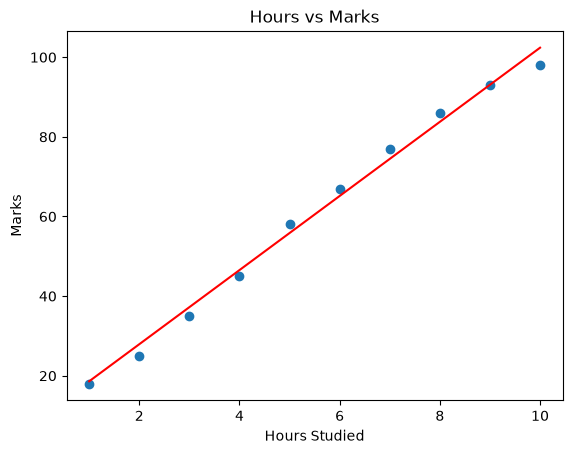

In [29]:
plt.scatter(x, y)
plt.plot(x, model.predict(x), color="red")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

In [32]:
hours = float(input("enter study hours: "))

enter study hours:  7.5


In [33]:
prediction = model.predict([[hours]])
print("Predicted Marks:", prediction[0])

Predicted Marks: 79.12068965517241


C:\Users\aryan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [40]:
print(type(x_train))

<class 'pandas.DataFrame'>


In [41]:
print(type(y_train))

<class 'pandas.Series'>


In [42]:
print(y_train.shape)

(8,)


In [43]:
print(x_train.shape)

(8, 1)


In [44]:
print(data)

   Hours  Marks
0      1     18
1      2     25
2      3     35
3      4     45
4      5     58
5      6     67
6      7     77
7      8     86
8      9     93
9     10     98


In [45]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'student_marks_prediction.ipynb']


In [46]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [47]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'model.pkl', 'student_marks_prediction.ipynb']
